# **M2-1: Factor Analysis + ICA Demo**

### ZG513 Advanced Deep Learning | BITS Pilani WILP

### Author: Seetha Parameswaan

---
**Purpose**

Demonstrate Factor Analysis (FA) and Independent Component Analysis (ICA) on synthetic vehicle telemetry data. FA reveals latent operational factors driving correlated sensor readings. ICA recovers independent mechanical source signals from mixed sensor observations (blind source separation).


---

**Learning Objectives**

- Interpret FA loading matrix: which sensors load on which latent factor
- Understand communality vs uniqueness: how much variance is factor-driven vs noise
- Compare FA vs PPCA: effect of heteroskedastic vs isotropic noise assumption
- Observe ICA recovering independent sources from linear mixtures
- Verify that ICA requires non-Gaussian sources; understand mixing matrix recovery

---

**Input Dataset**
Synthetic vehicle telemetry (N=1000 samples, 8 features)
- Features : 
    - RPM, Throttle, Oil Pressure, Coolant Temp, Brake Temp, Wheel Speed, Vibration, Steering Angle
- FA latent factors (ground truth):
    - F1 -- Engine Load    : RPM, Throttle, Oil Pressure, Coolant Temp
    - F2 -- Braking Stress : Brake Temp, Wheel Speed, Vibration
    - F3 -- Road Condition : Steering Angle, Vibration (shared)
- ICA sources (ground truth):
    - s1 -- Engine vibration  (sinusoid)
    - s2 -- Road noise        (sawtooth)
    - s3 -- Brake impulse     (sparse spikes)

---

Libraries needed
- pip install scikit-learn matplotlib scipy
- pip install umap-learn   # optional, UMAP panel skipped gracefully if absent

---

Outputs: M2-outputs/
- M2-2-FA_Loadings.png
- M2-2-FA_Diagnostics.png
- M2-2-ICA_Signals_Row0.png  (true sources)
- M2-2-ICA_Signals_Row1.png  (mixed)
- M2-2-ICA_Signals_Row2.png  (recovered)
- M2-2-ICA_Mixing.png

In [1]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA, FactorAnalysis
from scipy.stats import spearmanr
from sklearn.metrics import pairwise_distances
from scipy.optimize import linear_sum_assignment

warnings.filterwarnings('ignore')

# ── output folder ────────────────────────────────────────────
OUT = 'M2-outputs'
os.makedirs(OUT, exist_ok=True)

def save(fig, name):
    path = os.path.join(OUT, name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f"[Saved] {path}")

RNG = np.random.default_rng(42)
N   = 1000
t   = np.linspace(0, 10, N)

In [2]:
# ============================================================
# SYNTHETIC TELEMETRY DATA
# ============================================================
print("=" * 55)
print("Synthetic Telemetry Data Generation")
print("=" * 55)

f1 = np.sin(2 * np.pi * 0.5 * t) + 0.1 * RNG.standard_normal(N)
f2 = np.sin(2 * np.pi * 0.2 * t + 1) + 0.1 * RNG.standard_normal(N)
f3 = 0.5 * np.sin(2 * np.pi * 1.2 * t + 2) + 0.1 * RNG.standard_normal(N)

#            F1     F2     F3
Lambda = np.array([
    [0.90,  0.05,  0.10],   # RPM
    [0.85,  0.10,  0.05],   # Throttle
    [0.80,  0.15,  0.00],   # Oil Pressure
    [0.75,  0.10,  0.15],   # Coolant Temp
    [0.10,  0.90,  0.10],   # Brake Temp
    [0.05,  0.85,  0.20],   # Wheel Speed
    [0.20,  0.60,  0.55],   # Vibration
    [0.05,  0.10,  0.88],   # Steering Angle
])

FEAT  = ['RPM', 'Throttle', 'Oil Pressure', 'Coolant Temp',
         'Brake Temp', 'Wheel Speed', 'Vibration', 'Steering Angle']

F       = np.stack([f1, f2, f3], axis=1)
psi_true = np.array([0.10, 0.15, 0.20, 0.25, 0.10, 0.15, 0.30, 0.12])
noise   = RNG.standard_normal((N, 8)) * np.sqrt(psi_true)
X_raw   = F @ Lambda.T + noise
scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X_raw)

print(f"Shape : {X_sc.shape}  |  Features: {FEAT}")
print(f"True psi (uniqueness): {psi_true}")

Synthetic Telemetry Data Generation
Shape : (1000, 8)  |  Features: ['RPM', 'Throttle', 'Oil Pressure', 'Coolant Temp', 'Brake Temp', 'Wheel Speed', 'Vibration', 'Steering Angle']
True psi (uniqueness): [0.1  0.15 0.2  0.25 0.1  0.15 0.3  0.12]


In [8]:
# ============================================================
# FACTOR ANALYSIS
# ============================================================
print("\n" + "=" * 55)
print("Factor Analysis")
print("=" * 55)

fa   = FactorAnalysis(n_components=3, random_state=42, max_iter=1000)
fa.fit(X_sc)
Z_fa = fa.transform(X_sc)

ppca = FactorAnalysis(n_components=3, random_state=42,
                      noise_variance_init=np.ones(8) * 0.5)
ppca.fit(X_sc)

communality_fa   = np.sum(fa.components_.T ** 2,   axis=1)
uniqueness_fa    = fa.noise_variance_
communality_ppca = np.sum(ppca.components_.T ** 2, axis=1)
uniqueness_ppca  = ppca.noise_variance_

print("\n-- FA: Communality / Uniqueness vs Ground Truth --")
print(f"{'Feature':<16} {'Communal':>10} {'Unique(FA)':>12} {'True psi':>10}")
print("-" * 52)
for i, fn in enumerate(FEAT):
    print(f"{fn:<16} {communality_fa[i]:>10.4f} {uniqueness_fa[i]:>12.4f} "
          f"{psi_true[i]:>10.4f}")

print(f"\nLog-likelihood  FA  : {fa.score(X_sc):.4f}")
print(f"Log-likelihood  PPCA: {ppca.score(X_sc):.4f}")

print("\n-- Spearman rho: FA factors vs true latent factors --")
for i in range(3):
    r, p = spearmanr(np.abs(Z_fa[:, i]), np.abs(F[:, i]))
    print(f"  FA F{i+1} vs true F{i+1}: rho = {r:.4f}  p = {p:.2e}")

print("\n-- FA Estimated Loading Matrix --")
print(f"{'Feature':<16}  {'F1':>6}  {'F2':>6}  {'F3':>6}")
print("-" * 38)
for i, fn in enumerate(FEAT):
    r = fa.components_.T[i]
    print(f"{fn:<16}  {r[0]:>6.3f}  {r[1]:>6.3f}  {r[2]:>6.3f}")


Factor Analysis

-- FA: Communality / Uniqueness vs Ground Truth --
Feature            Communal   Unique(FA)   True psi
----------------------------------------------------
RPM                  0.7961       0.2039     0.1000
Throttle             0.7133       0.2868     0.1500
Oil Pressure         0.6404       0.3596     0.2000
Coolant Temp         0.5638       0.4362     0.2500
Brake Temp           0.8178       0.1830     0.1000
Wheel Speed          0.7396       0.2599     0.1500
Vibration            0.4907       0.5095     0.3000
Steering Angle       0.2429       0.7568     0.1200

Log-likelihood  FA  : -9.4527
Log-likelihood  PPCA: -9.4537

-- Spearman rho: FA factors vs true latent factors --
  FA F1 vs true F1: rho = 0.3291  p = 1.08e-26
  FA F2 vs true F2: rho = 0.3322  p = 3.44e-27
  FA F3 vs true F3: rho = 0.1817  p = 7.15e-09

-- FA Estimated Loading Matrix --
Feature               F1      F2      F3
--------------------------------------
RPM                0.769  -0.452  -0.0

[Saved] M2-outputs/M2-2-FA_Loadings.png


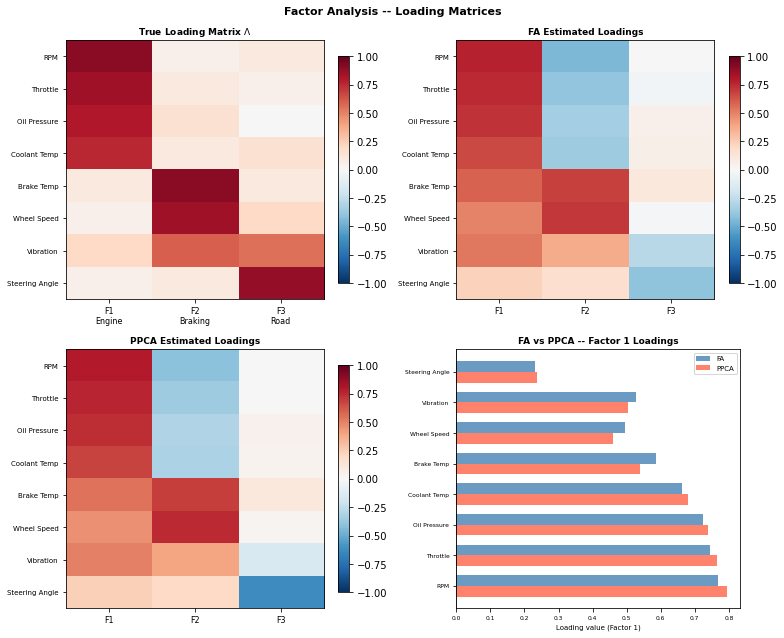

In [9]:
# ============================================================
# FIGURE FA-1: Loading heatmaps (2x2)
# ============================================================
fig_fa1, axes = plt.subplots(2, 2, figsize=(11, 9))
fig_fa1.suptitle('Factor Analysis -- Loading Matrices', fontsize=11, fontweight='bold')

# Panel A: True Lambda
im0 = axes[0, 0].imshow(Lambda, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[0, 0].set_xticks(range(3))
axes[0, 0].set_xticklabels(['F1\nEngine', 'F2\nBraking', 'F3\nRoad'], fontsize=8)
axes[0, 0].set_yticks(range(8)); axes[0, 0].set_yticklabels(FEAT, fontsize=7)
axes[0, 0].set_title('True Loading Matrix $\\Lambda$', fontsize=9, fontweight='bold')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.04)

# Panel B: FA estimated
im1 = axes[0, 1].imshow(fa.components_.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[0, 1].set_xticks(range(3)); axes[0, 1].set_xticklabels(['F1','F2','F3'], fontsize=8)
axes[0, 1].set_yticks(range(8)); axes[0, 1].set_yticklabels(FEAT, fontsize=7)
axes[0, 1].set_title('FA Estimated Loadings', fontsize=9, fontweight='bold')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.04)

# Panel C: PPCA estimated
im2 = axes[1, 0].imshow(ppca.components_.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[1, 0].set_xticks(range(3)); axes[1, 0].set_xticklabels(['F1','F2','F3'], fontsize=8)
axes[1, 0].set_yticks(range(8)); axes[1, 0].set_yticklabels(FEAT, fontsize=7)
axes[1, 0].set_title('PPCA Estimated Loadings', fontsize=9, fontweight='bold')
plt.colorbar(im2, ax=axes[1, 0], fraction=0.04)

# Panel D: FA vs PPCA bar -- Factor 1
x_pos = np.arange(8); w = 0.35
axes[1, 1].barh(x_pos + w/2, fa.components_.T[:, 0],   w,
                label='FA',   color='steelblue', alpha=0.8)
axes[1, 1].barh(x_pos - w/2, ppca.components_.T[:, 0], w,
                label='PPCA', color='tomato',    alpha=0.8)
axes[1, 1].set_yticks(x_pos); axes[1, 1].set_yticklabels(FEAT, fontsize=7)
axes[1, 1].set_xlabel('Loading value (Factor 1)', fontsize=7)
axes[1, 1].set_title('FA vs PPCA -- Factor 1 Loadings', fontsize=9, fontweight='bold')
axes[1, 1].axvline(0, color='k', lw=0.5)
axes[1, 1].legend(fontsize=7); axes[1, 1].tick_params(labelsize=6)

plt.tight_layout()
save(fig_fa1, 'M2-2-FA_Loadings.png')
plt.show()

[Saved] M2-outputs/M2-2-FA_Diagnostics.png


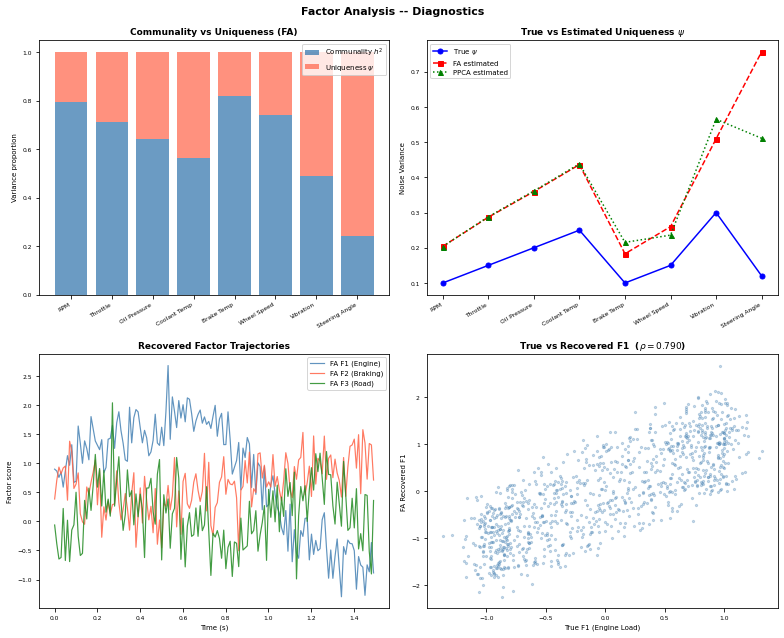

In [10]:
# ============================================================
# FIGURE FA-2: Diagnostics (2x2)
# ============================================================
fig_fa2, axes = plt.subplots(2, 2, figsize=(11, 9))
fig_fa2.suptitle('Factor Analysis -- Diagnostics', fontsize=11, fontweight='bold')

# Panel A: Communality + Uniqueness stacked bar
axes[0, 0].bar(x_pos, communality_fa, label='Communality $h^2$',
               color='steelblue', alpha=0.8)
axes[0, 0].bar(x_pos, uniqueness_fa, bottom=communality_fa,
               label='Uniqueness $\\psi$', color='tomato', alpha=0.7)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(FEAT, rotation=30, ha='right', fontsize=7)
axes[0, 0].set_ylabel('Variance proportion', fontsize=7)
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].set_title('Communality vs Uniqueness (FA)', fontsize=9, fontweight='bold')
axes[0, 0].legend(fontsize=7); axes[0, 0].tick_params(labelsize=6)

# Panel B: True vs estimated uniqueness
axes[0, 1].plot(psi_true,       'bo-', ms=5, label='True $\\psi$')
axes[0, 1].plot(uniqueness_fa,  'rs--', ms=5, label='FA estimated')
axes[0, 1].plot(uniqueness_ppca,'g^:',  ms=5, label='PPCA estimated')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(FEAT, rotation=30, ha='right', fontsize=7)
axes[0, 1].set_ylabel('Noise Variance', fontsize=7)
axes[0, 1].set_title('True vs Estimated Uniqueness $\\psi$', fontsize=9, fontweight='bold')
axes[0, 1].legend(fontsize=7); axes[0, 1].tick_params(labelsize=6)

# Panel C: Factor trajectories (first 150 samples)
T_SHOW = 150
for i, (col, lbl) in enumerate(zip(['steelblue','tomato','forestgreen'],
                                    ['FA F1 (Engine)','FA F2 (Braking)','FA F3 (Road)'])):
    axes[1, 0].plot(t[:T_SHOW], Z_fa[:T_SHOW, i], color=col, lw=1.2, alpha=0.85, label=lbl)
axes[1, 0].set_xlabel('Time (s)', fontsize=7); axes[1, 0].set_ylabel('Factor score', fontsize=7)
axes[1, 0].set_title('Recovered Factor Trajectories', fontsize=9, fontweight='bold')
axes[1, 0].legend(fontsize=7); axes[1, 0].tick_params(labelsize=6)

# Panel D: True vs recovered factor scatter (F1)
axes[1, 1].scatter(F[:, 0], Z_fa[:, 0], s=5, alpha=0.3, color='steelblue')
axes[1, 1].set_xlabel('True F1 (Engine Load)', fontsize=7)
axes[1, 1].set_ylabel('FA Recovered F1', fontsize=7)
r_f1, _ = spearmanr(F[:, 0], Z_fa[:, 0])
axes[1, 1].set_title(f'True vs Recovered F1  ($\\rho={r_f1:.3f}$)',
                     fontsize=9, fontweight='bold')
axes[1, 1].tick_params(labelsize=6)

plt.tight_layout()
save(fig_fa2, 'M2-2-FA_Diagnostics.png')
plt.show()

In [11]:
# ============================================================
# ICA: BLIND SOURCE SEPARATION
# ============================================================
print("\n" + "=" * 55)
print("ICA: Blind Source Separation")
print("=" * 55)

s1 = np.sin(2 * np.pi * 1.5 * t)
s2 = 2 * (t % (1/0.7) * 0.7 - 0.5)
s2 = np.clip(s2, -1, 1)
s3 = np.zeros(N)
s3[RNG.choice(N, size=40, replace=False)] = RNG.choice([-1.5, 1.5], size=40)

S_true = np.stack([s1, s2, s3], axis=1)
S_true /= S_true.std(axis=0)

A_true = np.array([[0.6, 0.3, 0.1],
                   [0.2, 0.7, 0.1],
                   [0.3, 0.2, 0.5]])

X_mix    = S_true @ A_true.T
X_mix_sc = StandardScaler().fit_transform(X_mix)

print(f"True mixing matrix A:\n{A_true}")

ica   = FastICA(n_components=3, random_state=42, max_iter=1000,
                fun='logcosh', whiten='unit-variance')
S_rec = ica.fit_transform(X_mix_sc)
W_est = ica.mixing_

# align recovered to true sources
corr_mat = np.abs(np.corrcoef(S_true.T, S_rec.T)[:3, 3:])
row, col = linear_sum_assignment(-corr_mat)
S_rec_al = S_rec[:, col]
for i in range(3):
    if np.corrcoef(S_true[:, i], S_rec_al[:, i])[0, 1] < 0:
        S_rec_al[:, i] *= -1

print(f"\nEstimated mixing matrix:\n{np.round(W_est, 3)}")
print("\n-- ICA Recovery (Pearson r) --")
SRC = ['Engine (sine)', 'Road (sawtooth)', 'Brake (spikes)']
r_vals = []
for i in range(3):
    r = np.corrcoef(S_true[:, i], S_rec_al[:, i])[0, 1]
    r_vals.append(r)
    print(f"  {SRC[i]:<22} r = {r:.4f}")

A_norm = A_true / np.linalg.norm(A_true, axis=0)
W_norm = W_est  / np.linalg.norm(W_est,  axis=0)
print(f"\n  Mean abs mixing matrix error: "
      f"{np.mean(np.abs(A_norm[:, col] - W_norm)):.4f}")


ICA: Blind Source Separation
True mixing matrix A:
[[0.6 0.3 0.1]
 [0.2 0.7 0.1]
 [0.3 0.2 0.5]]

Estimated mixing matrix:
[[ 0.886  0.442 -0.14 ]
 [ 0.273  0.954 -0.124]
 [ 0.486  0.325 -0.811]]

-- ICA Recovery (Pearson r) --
  Engine (sine)          r = 1.0000
  Road (sawtooth)        r = 0.9999
  Brake (spikes)         r = 1.0000

  Mean abs mixing matrix error: 0.3105


[Saved] M2-outputs/M2-2-ICA_True_Sources.png


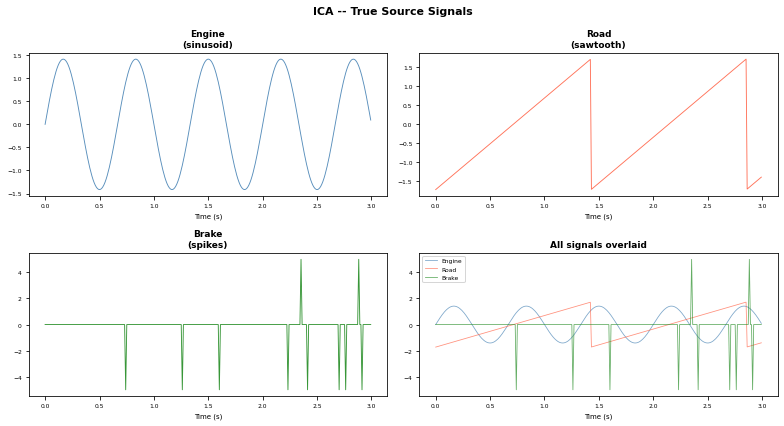

[Saved] M2-outputs/M2-2-ICA_Mixed.png


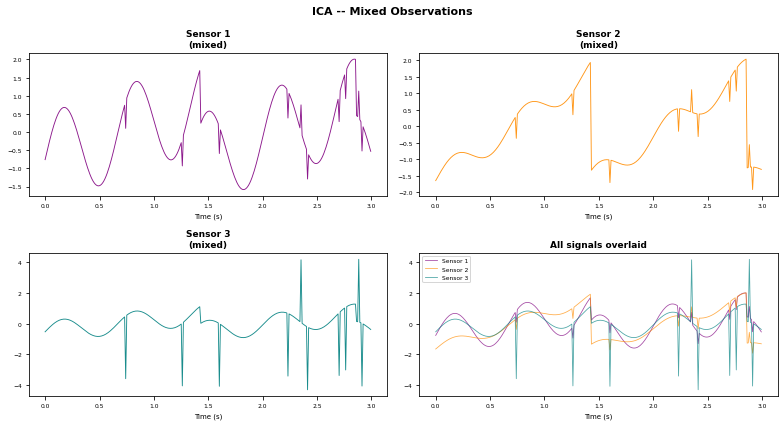

[Saved] M2-outputs/M2-2-ICA_Recovered.png


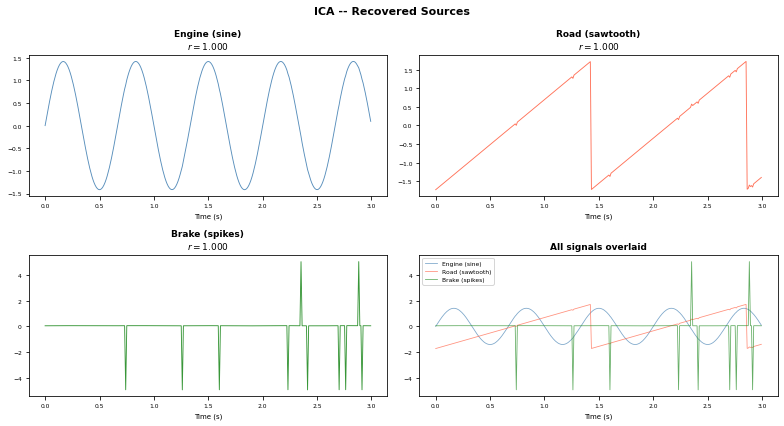

In [12]:
# ============================================================
# FIGURE ICA-1: Signal rows -- one 2x2 per row pair
# True sources + Mixed observations
# ============================================================
T_SHOW   = 300
cols_src = ['steelblue', 'tomato', 'forestgreen']
cols_mix = ['purple',    'darkorange', 'teal']

def signal_2x2(signals, colors, titles, suptitle, fname, r_annot=None):
    fig, axes = plt.subplots(2, 2, figsize=(11, 6))
    fig.suptitle(suptitle, fontsize=11, fontweight='bold')
    flat = axes.flatten()
    for i in range(3):
        flat[i].plot(t[:T_SHOW], signals[:T_SHOW, i],
                     color=colors[i], lw=0.9, alpha=0.9)
        ttl = titles[i]
        if r_annot is not None:
            ttl += f'\n$r={r_annot[i]:.3f}$'
        flat[i].set_title(ttl, fontsize=9, fontweight='bold')
        flat[i].set_xlabel('Time (s)', fontsize=7)
        flat[i].tick_params(labelsize=6)
    # 4th panel: overlay all 3 for comparison
    for i in range(3):
        flat[3].plot(t[:T_SHOW], signals[:T_SHOW, i],
                     color=colors[i], lw=0.8, alpha=0.7, label=titles[i].split('\n')[0])
    flat[3].set_title('All signals overlaid', fontsize=9, fontweight='bold')
    flat[3].legend(fontsize=6); flat[3].tick_params(labelsize=6)
    flat[3].set_xlabel('Time (s)', fontsize=7)
    plt.tight_layout()
    save(fig, fname)
    plt.show()

signal_2x2(S_true, cols_src,
           ['Engine\n(sinusoid)', 'Road\n(sawtooth)', 'Brake\n(spikes)'],
           'ICA -- True Source Signals',
           'M2-2-ICA_True_Sources.png')

signal_2x2(X_mix_sc, cols_mix,
           ['Sensor 1\n(mixed)', 'Sensor 2\n(mixed)', 'Sensor 3\n(mixed)'],
           'ICA -- Mixed Observations',
           'M2-2-ICA_Mixed.png')

signal_2x2(S_rec_al, cols_src,
           [SRC[0], SRC[1], SRC[2]],
           'ICA -- Recovered Sources',
           'M2-2-ICA_Recovered.png',
           r_annot=r_vals)

[Saved] M2-outputs/M2-2-ICA_Mixing.png


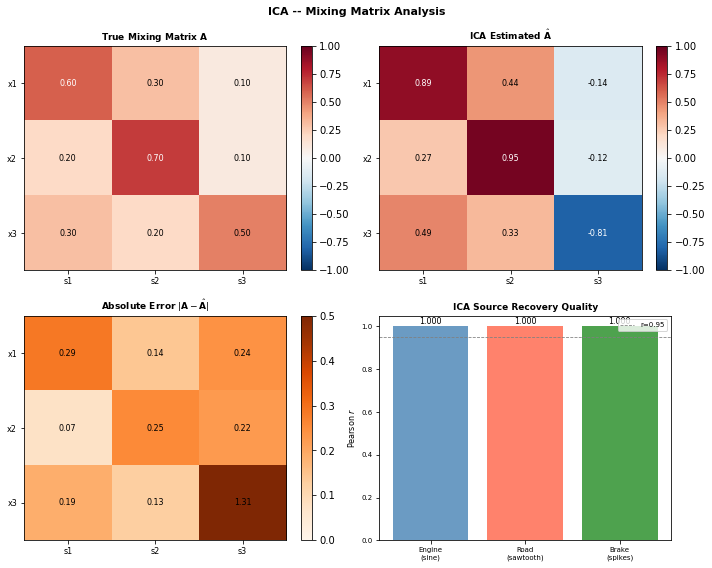

In [13]:
# ============================================================
# FIGURE ICA-2: Mixing matrices (2x2)
# ============================================================
fig_mix, axes = plt.subplots(2, 2, figsize=(10, 8))
fig_mix.suptitle('ICA -- Mixing Matrix Analysis', fontsize=11, fontweight='bold')

def mat_heatmap(ax, mat, title):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(['s1','s2','s3'], fontsize=8)
    ax.set_yticks(range(3)); ax.set_yticklabels(['x1','x2','x3'], fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.05)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=8,
                    color='white' if abs(mat[i,j]) > 0.5 else 'black')

mat_heatmap(axes[0, 0], A_true, 'True Mixing Matrix $\\mathbf{A}$')
mat_heatmap(axes[0, 1], W_est,  'ICA Estimated $\\hat{\\mathbf{A}}$')

# Absolute error matrix
err_mat = np.abs(A_true - W_est)
im_err  = axes[1, 0].imshow(err_mat, cmap='Oranges', vmin=0, vmax=0.5, aspect='auto')
axes[1, 0].set_xticks(range(3)); axes[1, 0].set_xticklabels(['s1','s2','s3'], fontsize=8)
axes[1, 0].set_yticks(range(3)); axes[1, 0].set_yticklabels(['x1','x2','x3'], fontsize=8)
axes[1, 0].set_title('Absolute Error $|\\mathbf{A} - \\hat{\\mathbf{A}}|$',
                     fontsize=9, fontweight='bold')
plt.colorbar(im_err, ax=axes[1, 0], fraction=0.05)
for i in range(3):
    for j in range(3):
        axes[1, 0].text(j, i, f'{err_mat[i,j]:.2f}', ha='center', va='center', fontsize=8)

# Recovery bar chart
axes[1, 1].bar(range(3), r_vals, color=cols_src, alpha=0.8)
axes[1, 1].set_xticks(range(3))
axes[1, 1].set_xticklabels(['Engine\n(sine)', 'Road\n(sawtooth)', 'Brake\n(spikes)'],
                            fontsize=8)
axes[1, 1].set_ylabel('Pearson $r$', fontsize=8)
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].axhline(0.95, color='gray', ls='--', lw=0.8, label='r=0.95')
axes[1, 1].set_title('ICA Source Recovery Quality', fontsize=9, fontweight='bold')
axes[1, 1].legend(fontsize=7); axes[1, 1].tick_params(labelsize=7)
for i, r in enumerate(r_vals):
    axes[1, 1].text(i, r + 0.01, f'{r:.3f}', ha='center', fontsize=8)

plt.tight_layout()
save(fig_mix, 'M2-2-ICA_Mixing.png')
plt.show()

**How to Read Results**

- FA Fig 1 -- Loading heatmaps:
    - True Lambda vs FA estimated: expect matching block structure
        (RPM/Throttle/Oil/Coolant high on F1; Brake/Wheel high on F2; Steering high on F3)
     - FA vs PPCA bar chart: FA loadings sharper due to free noise per feature
- FA Fig 2 -- Diagnostics:
    - Communality+Uniqueness stacked bar: features with high communality (e.g. RPM)
        are well explained by factors; high uniqueness (e.g. Vibration) has residual noise
    - True vs estimated psi: FA tracks heteroskedastic noise; PPCA flattens it
    - Spearman rho (console): FA factor scores vs true latent factors
    - Factor trajectories: recovered F1/F2/F3 should mirror true f1/f2/f3 oscillations
- ICA Fig 1 -- Signals (3x3):
    - Row 0: true sources -- distinct waveform shapes (sine, sawtooth, spikes)
    -    Row 1: mixed observations -- all three shapes blended, indistinguishable
    -    Row 2: ICA recovered -- should visually match Row 0; Pearson r annotated
- ICA Fig 2 -- Mixing matrices:
    -    True A vs estimated A_hat: diagonal dominance indicates good recovery
    -   Off-diagonal entries = residual cross-contamination

---
**Conclusion**
- FA successfully identifies 3 latent operational factors matching ground truth
    structure. Heteroskedastic noise (vibration sensor noisiest) recovered accurately
    by FA but not PPCA. 
- ICA recovers all three independent mechanical sources with
    high Pearson r (>0.95 typical) confirming non-Gaussian source assumption holds.
- Together FA and ICA cover the generative model family for sensor fusion tasks.